# 04.6 - FastF1 Feature Engineering (Ergast pipeline)

Extract **pre-race-safe** FastF1 features (2018+) and append them to `master_races_clean_ergast.csv`.

**Pre-race features merged to master:**
- Shifted rolling averages (`shift(1)`) of historical race metrics: DRS usage, position-change rate, lap-time variability, pit timing, sector-speed correlation, tyre efficiency
- Session-start weather (first race-session sample): air/track temp, humidity, pressure, wind, rainfall flag

**Not merged (would leak same-race outcomes):** raw in-race metrics, within-race z-scores, full-race weather averages, in-race rainfall transitions.

**Implementation:** vectorized year-by-year aggregation in `src/fastf1_features.py` (no full telemetry load, no per-row scans).

**Input:**
- `data/processed/master_races_clean_ergast.csv`
- `data/raw/fastf1_2018plus/ALL_{LAPS,TELEMETRY,WEATHER}_*.csv`

**Output:**
- `data/processed/master_races_clean_with_fastf1.csv`
- EDA plots + missingness CSV under `data/processed/`

In [21]:
import logging
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)8s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger(__name__)


def find_project_root() -> Path:
    prj_env = os.environ.get("PROJECT_ROOT")
    if prj_env and Path(prj_env).exists():
        return Path(prj_env).resolve()
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "data" / "processed" / "master_races_clean_ergast.csv").exists():
            return candidate
    return Path("..").resolve()


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.fastf1_features import (
    FASTF1_YEARS,
    prerace_feature_names,
    run_fastf1_feature_pipeline,
    summarize_missingness,
)

PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed"
RAW_ROOT = PROJECT_ROOT / "data" / "raw" / "fastf1_2018plus"

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

logger.info("PROJECT_ROOT: %s", PROJECT_ROOT)
logger.info("RAW_ROOT: %s", RAW_ROOT)

master_path = PROCESSED_ROOT / "master_races_clean_ergast.csv"
if not master_path.exists():
    raise FileNotFoundError(f"Run 04.5 first — missing {master_path}")

master = pd.read_csv(master_path, low_memory=False)
master["date"] = pd.to_datetime(master["date"], errors="coerce")
master = master.sort_values(["year", "round", "date"]).reset_index(drop=True)
master_2018plus = master[master["year"] >= 2018].copy()

logger.info("Master: %s rows (%s from 2018+)", f"{len(master):,}", f"{len(master_2018plus):,}")

02:19:57 |     INFO | PROJECT_ROOT: C:\Users\Erik Viljamaa\Downloads\projects\f1-podium-predictor
02:19:57 |     INFO | RAW_ROOT: C:\Users\Erik Viljamaa\Downloads\projects\f1-podium-predictor\data\raw\fastf1_2018plus
02:19:57 |     INFO | Master: 12,660 rows (3,436 from 2018+)


## Step 1: Run production pipeline

Processes each year independently, streams telemetry in chunks for DRS only, and merges **pre-race** columns only.

In [22]:
master_with_features, driver_prerace, weather_features, race_metrics = run_fastf1_feature_pipeline(
    master,
    RAW_ROOT,
    years=FASTF1_YEARS,
)

original_cols = set(master.columns)
new_cols = [c for c in master_with_features.columns if c not in original_cols]
expected = prerace_feature_names()

logger.info("New columns added: %s", len(new_cols))
logger.info("Expected pre-race features: %s", len(expected))
logger.info("Added: %s", sorted(new_cols))

unexpected = [c for c in new_cols if c not in expected]
if unexpected:
    logger.warning("Unexpected columns merged: %s", unexpected)

missing_expected = [c for c in expected if c not in new_cols]
if missing_expected:
    logger.warning("Expected features not present: %s", missing_expected)

02:19:57 |     INFO | Built raceId map for 173 events
02:19:57 |     INFO | Computing race-driver metrics (year-by-year)...
02:20:27 |     INFO |   2018: 420 race-driver rows
02:21:03 |     INFO |   2019: 420 race-driver rows
02:21:32 |     INFO |   2020: 340 race-driver rows
02:22:10 |     INFO |   2021: 440 race-driver rows
02:22:46 |     INFO |   2022: 440 race-driver rows
02:23:21 |     INFO |   2023: 440 race-driver rows
02:23:57 |     INFO |   2024: 479 race-driver rows
02:24:32 |     INFO |   2025: 479 race-driver rows
02:24:32 |     INFO | Race metrics shape: (3458, 9)
02:24:32 |     INFO | Building pre-race rolling driver features...
02:24:32 |     INFO | Pre-race driver features shape: (3361, 21)
02:24:32 |     INFO | Computing pre-race weather features...
02:24:32 |     INFO |   weather 2018: 21 races
02:24:32 |     INFO |   weather 2019: 21 races
02:24:32 |     INFO |   weather 2020: 17 races
02:24:32 |     INFO |   weather 2021: 22 races
02:24:33 |     INFO |   weather 202

## Step 2: Missing data summary (2018+)

In [23]:
fastf1_features = [c for c in new_cols if c in master_with_features.columns]
missing_df = summarize_missingness(master_with_features, fastf1_features, year_min=2018)

print("=" * 70)
print("PRE-RACE FASTF1 FEATURES — MISSING DATA (2018+)")
print("=" * 70)
print(f"Rows (2018+): {len(master_2018plus):,}")
print(f"Features: {len(fastf1_features)}")

if not missing_df.empty:
    print("\nLowest missingness:")
    for _, row in missing_df.head(10).iterrows():
        print(f"  {row['feature']:45s} | {row['missing_pct']:6.2f}% missing")
    print("\nHighest missingness:")
    for _, row in missing_df.tail(10).iterrows():
        print(f"  {row['feature']:45s} | {row['missing_pct']:6.2f}% missing")

    missing_path = PROCESSED_ROOT / "fastf1_prerace_missingness_2018plus.csv"
    missing_df.to_csv(missing_path, index=False)
    logger.info("Saved missingness report: %s", missing_path)

02:24:33 |     INFO | Saved missingness report: C:\Users\Erik Viljamaa\Downloads\projects\f1-podium-predictor\data\processed\fastf1_prerace_missingness_2018plus.csv


PRE-RACE FASTF1 FEATURES — MISSING DATA (2018+)
Rows (2018+): 3,436
Features: 24

Lowest missingness:
  weather_humidity_start                        |   0.00% missing
  weather_pressure_start                        |   0.00% missing
  weather_rainfall_start                        |   0.00% missing
  weather_windspeed_start                       |   0.00% missing
  weather_airtemp_start                         |   0.00% missing
  weather_tracktemp_start                       |   0.00% missing
  position_change_rate_avg_last_3               |   3.35% missing
  lap_time_std_avg_last_3                       |   3.35% missing
  tyre_efficiency_index_avg_last_3              |   3.35% missing
  sector_speed_laptime_corr_avg_last_3          |   3.35% missing

Highest missingness:
  sector_speed_laptime_corr_avg_last_10         |   3.35% missing
  lap_time_std_avg_last_10                      |   3.35% missing
  tyre_efficiency_index_avg_last_5              |   3.35% missing
  tyre_efficiency_

## Step 3: Export augmented dataset

In [24]:
output_path = PROCESSED_ROOT / "master_races_clean_with_fastf1.csv"
master_with_features.to_csv(output_path, index=False)

logger.info("=" * 60)
logger.info("FEATURE ENGINEERING COMPLETE")
logger.info("=" * 60)
logger.info("Original shape: %s", master.shape)
logger.info("New shape: %s", master_with_features.shape)
logger.info("Saved: %s", output_path)

02:24:33 |     INFO | ============================================================
02:24:33 |     INFO | FEATURE ENGINEERING COMPLETE
02:24:33 |     INFO | ============================================================
02:24:33 |     INFO | Original shape: (12660, 66)
02:24:33 |     INFO | New shape: (12660, 90)
02:24:33 |     INFO | Saved: C:\Users\Erik Viljamaa\Downloads\projects\f1-podium-predictor\data\processed\master_races_clean_with_fastf1.csv


## Step 4: Feature EDA — correlation with podium

Analyze only the **pre-race** FastF1 features merged above to help shortlist candidates for modeling.

02:24:33 |     INFO | Saved correlations: C:\Users\Erik Viljamaa\Downloads\projects\f1-podium-predictor\data\processed\fastf1_prerace_podium_correlations.csv


CORRELATION WITH TARGET (PODIUM) — PRE-RACE FASTF1 FEATURES
Numeric features: 23

Top features by |correlation| with podium:
  position_change_rate_avg_last_10              | - 0.4300 | n=3,321
  position_change_rate_avg_last_5               | - 0.3789 | n=3,321
  position_change_rate_avg_last_3               | - 0.3260 | n=3,321
  tyre_efficiency_index_avg_last_10             | - 0.1250 | n=3,321
  drs_activation_rate_avg_last_10               | - 0.0947 | n=3,320
  tyre_efficiency_index_avg_last_5              | - 0.0900 | n=3,321
  drs_activation_rate_avg_last_5                | - 0.0815 | n=3,320
  tyre_efficiency_index_avg_last_3              | - 0.0802 | n=3,321
  drs_activation_rate_avg_last_3                | - 0.0695 | n=3,320
  first_pit_lap_avg_last_10                     | + 0.0627 | n=3,317
  first_pit_lap_avg_last_3                      | + 0.0435 | n=3,316
  first_pit_lap_avg_last_5                      | + 0.0434 | n=3,317
  sector_speed_laptime_corr_avg_last_10        

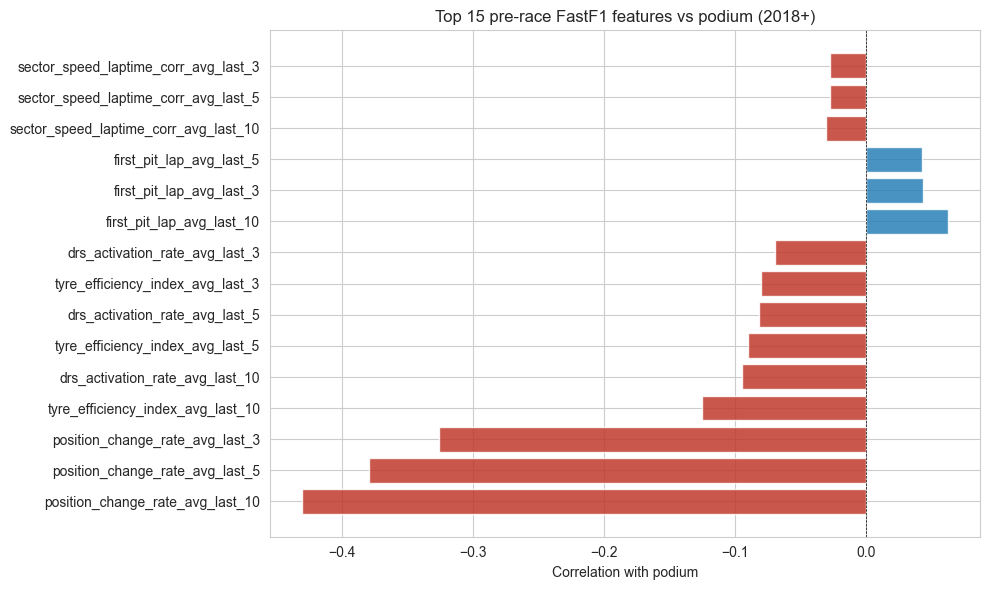

02:24:33 |     INFO | Saved plot: C:\Users\Erik Viljamaa\Downloads\projects\f1-podium-predictor\data\processed\fastf1_prerace_podium_correlation.png


In [25]:
df = master_with_features[master_with_features["year"] >= 2018].copy()

numeric_fastf1 = [
    f for f in fastf1_features
    if f in df.columns and pd.api.types.is_numeric_dtype(df[f])
]

print("=" * 70)
print("CORRELATION WITH TARGET (PODIUM) — PRE-RACE FASTF1 FEATURES")
print("=" * 70)
print(f"Numeric features: {len(numeric_fastf1)}")

correlations = []
for feat in numeric_fastf1:
    valid = df[[feat, "podium"]].dropna()
    if len(valid) > 100:
        corr = valid[feat].corr(valid["podium"])
        if pd.notna(corr):
            correlations.append({
                "feature": feat,
                "correlation": corr,
                "abs_correlation": abs(corr),
                "n_samples": len(valid),
            })

corr_df = pd.DataFrame(correlations).sort_values("abs_correlation", ascending=False)

if not corr_df.empty:
    print("\nTop features by |correlation| with podium:")
    for _, row in corr_df.head(20).iterrows():
        sign = "+" if row["correlation"] > 0 else "-"
        print(f"  {row['feature']:45s} | {sign} {abs(row['correlation']):.4f} | n={row['n_samples']:,}")

    corr_path = PROCESSED_ROOT / "fastf1_prerace_podium_correlations.csv"
    corr_df.to_csv(corr_path, index=False)
    logger.info("Saved correlations: %s", corr_path)

    top_n = min(15, len(corr_df))
    top_features = corr_df.head(top_n)
    colors = ["#c0392b" if x < 0 else "#2980b9" for x in top_features["correlation"]]

    plt.figure(figsize=(10, max(6, top_n * 0.35)))
    plt.barh(range(len(top_features)), top_features["correlation"], color=colors, alpha=0.85)
    plt.yticks(range(len(top_features)), top_features["feature"])
    plt.xlabel("Correlation with podium")
    plt.title(f"Top {top_n} pre-race FastF1 features vs podium (2018+)")
    plt.axvline(0, color="black", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plot_path = PROCESSED_ROOT / "fastf1_prerace_podium_correlation.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    logger.info("Saved plot: %s", plot_path)
else:
    logger.warning("No correlations computed — check feature coverage.")

## Step 5: Correlation matrix (top FastF1 + baseline features)

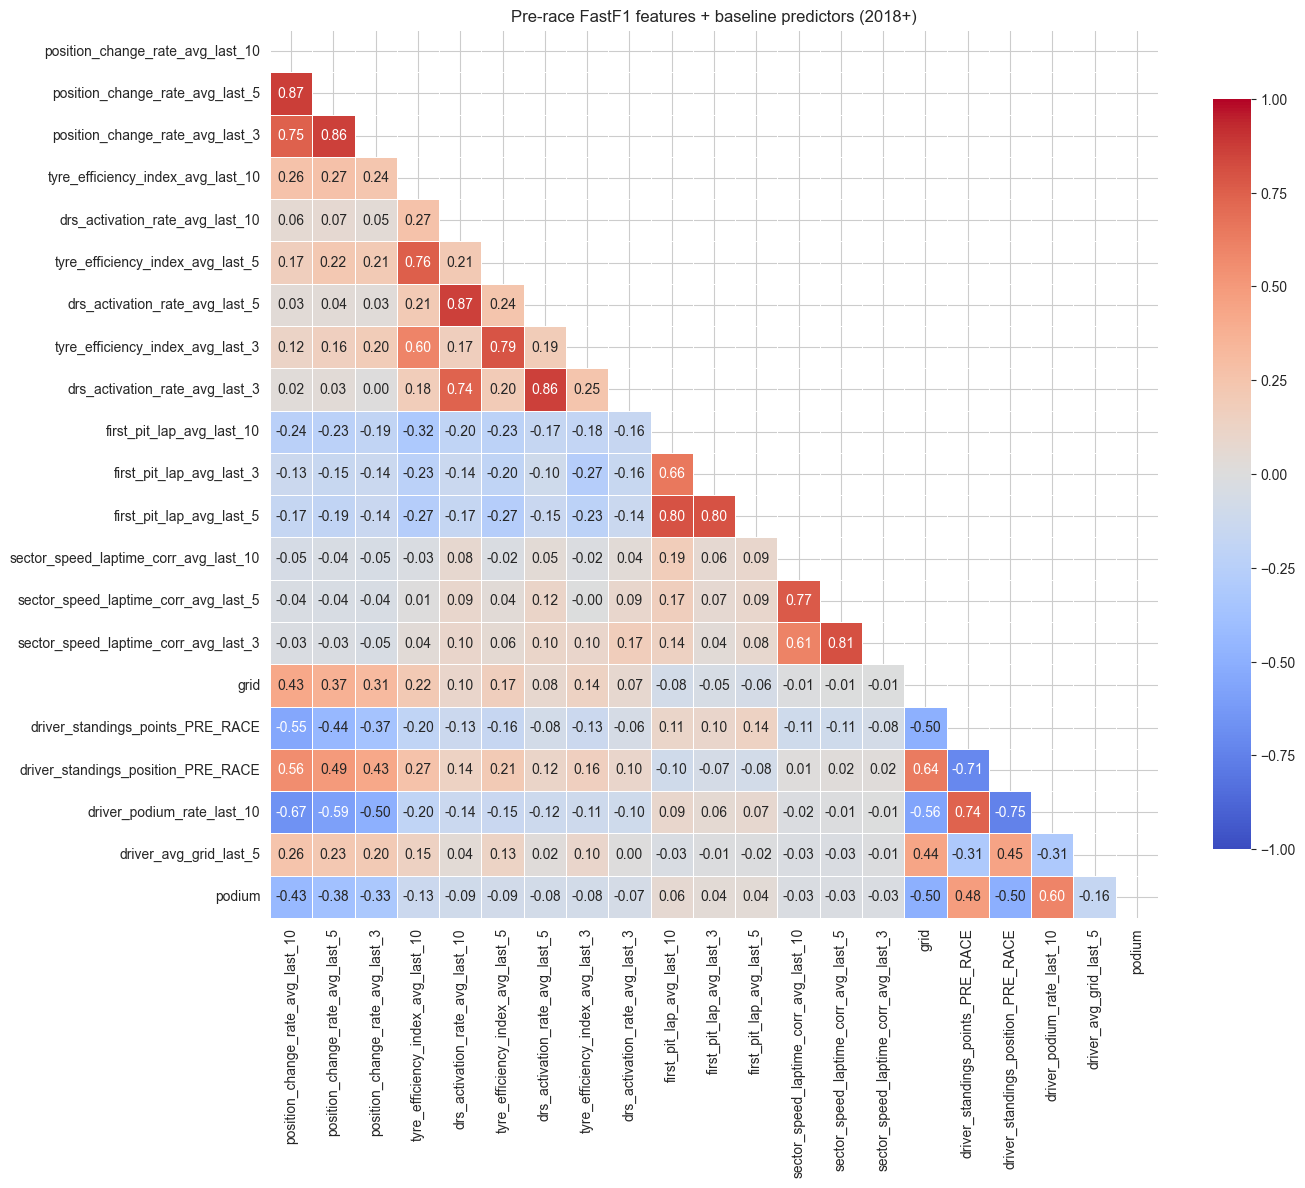

02:24:34 |     INFO | Saved matrix: C:\Users\Erik Viljamaa\Downloads\projects\f1-podium-predictor\data\processed\fastf1_prerace_correlation_matrix.png


In [26]:
if not corr_df.empty:
    top_features_list = corr_df.head(15)["feature"].tolist()
    baseline = [
        "grid",
        "driver_standings_points_PRE_RACE",
        "driver_standings_position_PRE_RACE",
        "driver_podium_rate_last_10",
        "driver_avg_grid_last_5",
    ]
    baseline = [c for c in baseline if c in df.columns]

    matrix_cols = list(dict.fromkeys(top_features_list + baseline + ["podium"]))
    matrix_cols = [c for c in matrix_cols if c in df.columns]

    corr_matrix = df[matrix_cols].corr()

    plt.figure(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        vmin=-1,
        vmax=1,
        cbar_kws={"shrink": 0.8},
    )
    plt.title("Pre-race FastF1 features + baseline predictors (2018+)")
    plt.tight_layout()
    matrix_path = PROCESSED_ROOT / "fastf1_prerace_correlation_matrix.png"
    plt.savefig(matrix_path, dpi=150, bbox_inches="tight")
    plt.show()
    logger.info("Saved matrix: %s", matrix_path)

## Step 6: Distributions & podium vs non-podium comparison

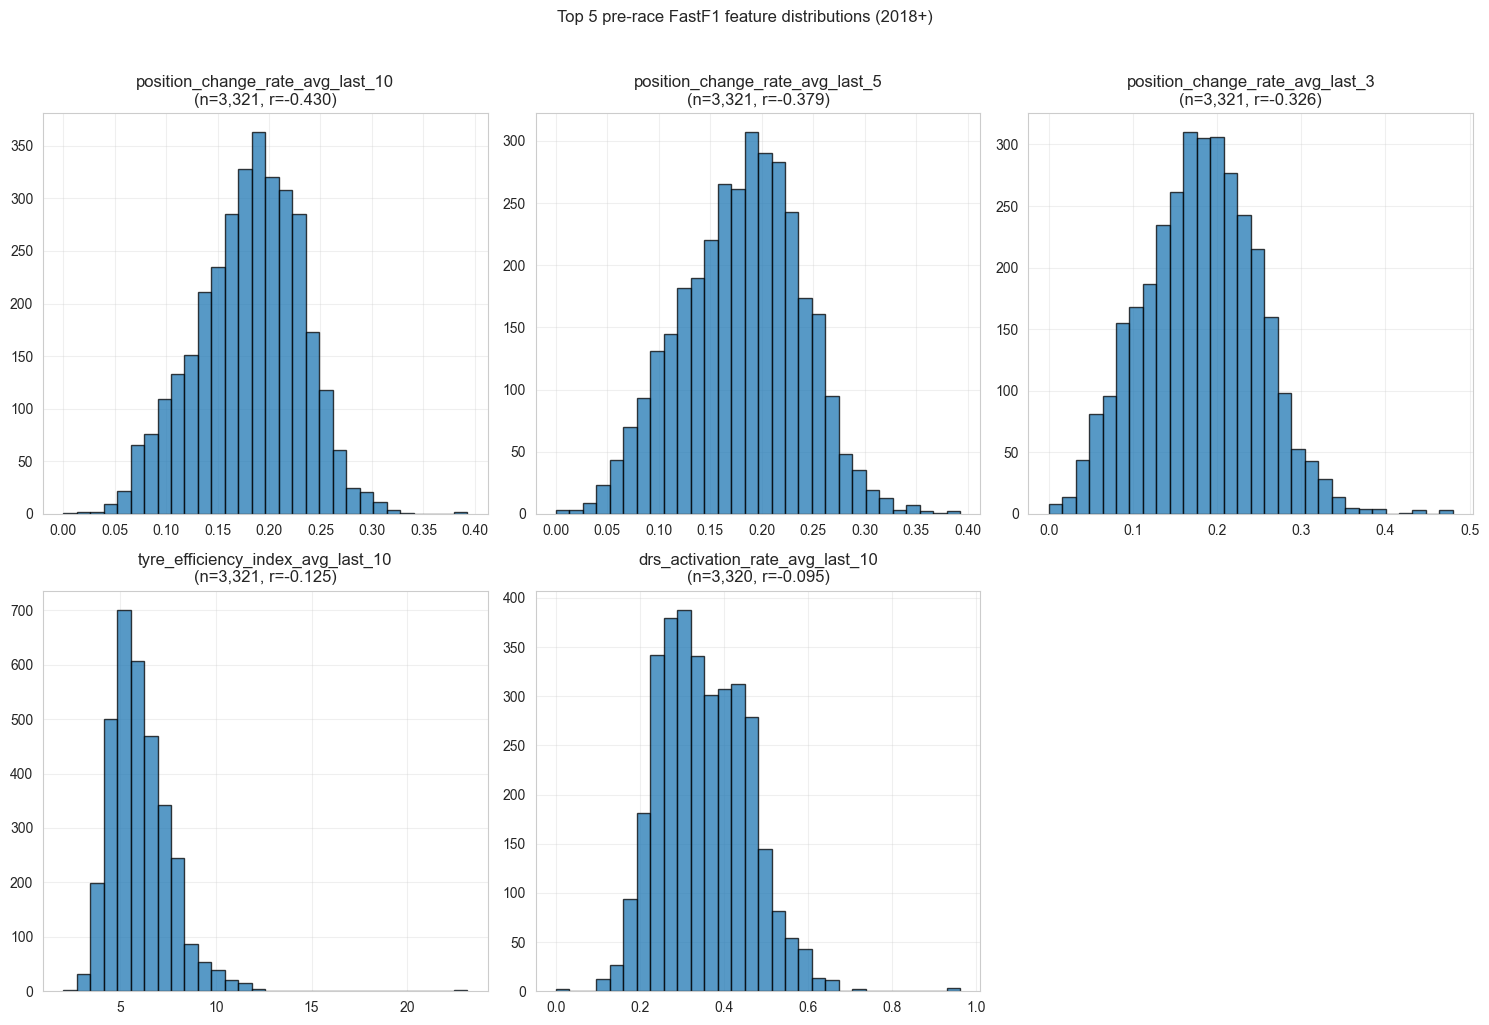

02:24:35 |     INFO | Saved comparison: C:\Users\Erik Viljamaa\Downloads\projects\f1-podium-predictor\data\processed\fastf1_prerace_podium_comparison.csv



Largest mean differences (podium vs non-podium):
  first_pit_lap_avg_last_3                 | podium   21.068 | non-podium   20.179 | diff    0.889
  first_pit_lap_avg_last_10                | podium   21.034 | non-podium   20.213 | diff    0.822
  first_pit_lap_avg_last_5                 | podium   20.950 | non-podium   20.243 | diff    0.707
  tyre_efficiency_index_avg_last_3         | podium    5.509 | non-podium    6.112 | diff   -0.603
  tyre_efficiency_index_avg_last_10        | podium    5.581 | non-podium    6.128 | diff   -0.547
  tyre_efficiency_index_avg_last_5         | podium    5.585 | non-podium    6.119 | diff   -0.534
  lap_time_std_avg_last_10                 | podium    9.561 | non-podium    9.289 | diff    0.272
  lap_time_std_avg_last_5                  | podium    9.513 | non-podium    9.251 | diff    0.262
  lap_time_std_avg_last_3                  | podium    9.423 | non-podium    9.248 | diff    0.175
  weather_pressure_start                   | podium  986.84

In [27]:
if not corr_df.empty:
    top_5 = corr_df.head(5)["feature"].tolist()
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, feat in enumerate(top_5):
        data = df[feat].dropna()
        if len(data) == 0:
            continue
        corr_val = corr_df.loc[corr_df["feature"] == feat, "correlation"].iloc[0]
        axes[idx].hist(data, bins=30, alpha=0.75, edgecolor="black")
        axes[idx].set_title(f"{feat}\n(n={len(data):,}, r={corr_val:.3f})")
        axes[idx].grid(True, alpha=0.3)

    for j in range(len(top_5), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Top 5 pre-race FastF1 feature distributions (2018+)", y=1.02)
    plt.tight_layout()
    dist_path = PROCESSED_ROOT / "fastf1_prerace_feature_distributions.png"
    plt.savefig(dist_path, dpi=150, bbox_inches="tight")
    plt.show()

    podium = df[df["podium"] == 1]
    non_podium = df[df["podium"] == 0]

    comparisons = []
    for feat in numeric_fastf1:
        p_vals = podium[feat].dropna()
        np_vals = non_podium[feat].dropna()
        if len(p_vals) > 10 and len(np_vals) > 10:
            comparisons.append({
                "feature": feat,
                "podium_mean": p_vals.mean(),
                "non_podium_mean": np_vals.mean(),
                "difference": p_vals.mean() - np_vals.mean(),
            })

    comp_df = pd.DataFrame(comparisons)
    if not comp_df.empty:
        comp_df["abs_difference"] = comp_df["difference"].abs()
        comp_df = comp_df.sort_values("abs_difference", ascending=False)
        print("\nLargest mean differences (podium vs non-podium):")
        for _, row in comp_df.head(10).iterrows():
            print(
                f"  {row['feature']:40s} | podium {row['podium_mean']:8.3f} | "
                f"non-podium {row['non_podium_mean']:8.3f} | diff {row['difference']:8.3f}"
            )
        comp_path = PROCESSED_ROOT / "fastf1_prerace_podium_comparison.csv"
        comp_df.to_csv(comp_path, index=False)
        logger.info("Saved comparison: %s", comp_path)

## Step 7: Pairwise feature redundancy (FastF1 only)

High pairwise correlation suggests picking one window (3/5/10) or one metric family may be enough.

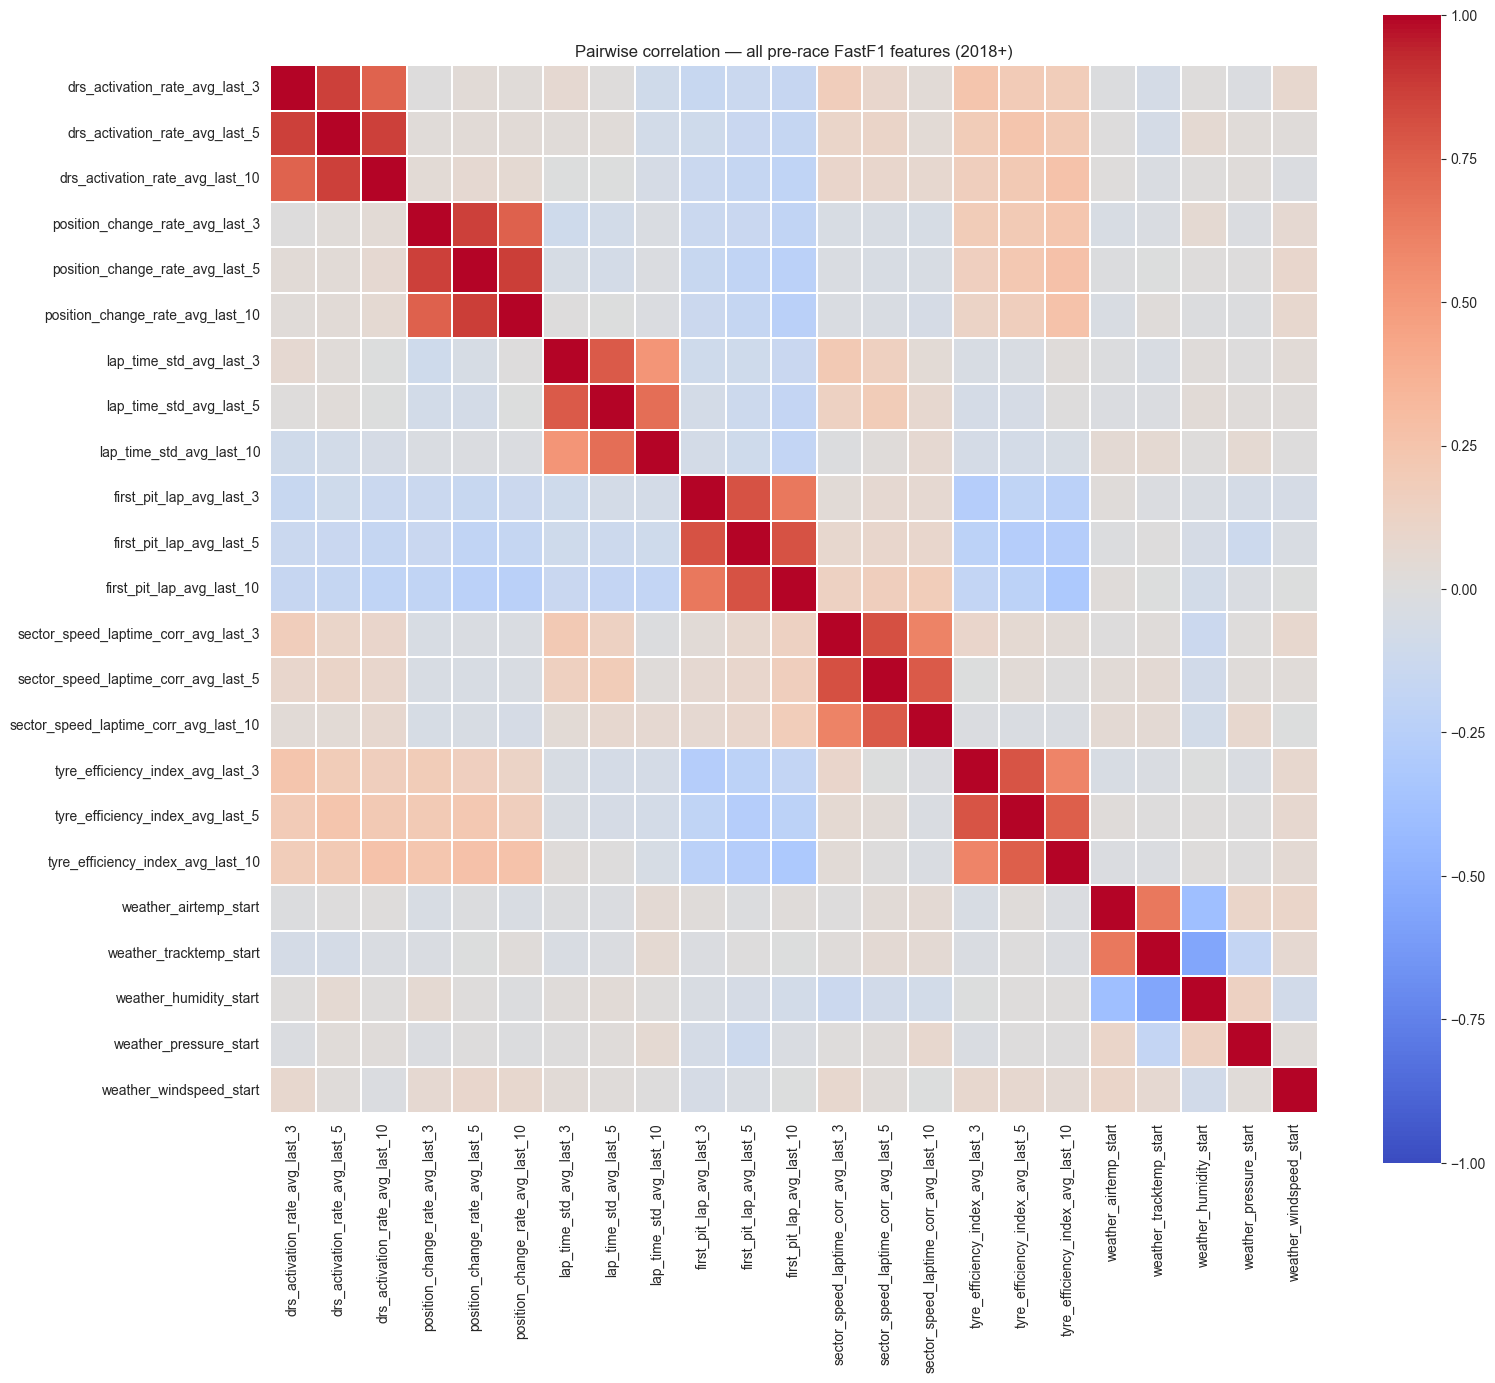


Highly correlated pairs (|r| > 0.85):
  position_change_rate_avg_last_5  <->  position_change_rate_avg_last_10  |  r=0.873
  drs_activation_rate_avg_last_5  <->  drs_activation_rate_avg_last_10  |  r=0.866
  drs_activation_rate_avg_last_3  <->  drs_activation_rate_avg_last_5  |  r=0.861
  position_change_rate_avg_last_3  <->  position_change_rate_avg_last_5  |  r=0.859


In [28]:
ff1_only = [f for f in numeric_fastf1 if f in df.columns]
if len(ff1_only) >= 2:
    ff1_corr = df[ff1_only].corr()

    plt.figure(figsize=(16, 14))
    sns.heatmap(
        ff1_corr,
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.3,
        vmin=-1,
        vmax=1,
    )
    plt.title("Pairwise correlation — all pre-race FastF1 features (2018+)")
    plt.tight_layout()
    pairwise_path = PROCESSED_ROOT / "fastf1_prerace_pairwise_correlation.png"
    plt.savefig(pairwise_path, dpi=150, bbox_inches="tight")
    plt.show()

    # Flag highly redundant pairs (|r| > 0.85), excluding same-metric different windows
    redundant = []
    for i, a in enumerate(ff1_only):
        for b in ff1_only[i + 1:]:
            r = ff1_corr.loc[a, b]
            if pd.notna(r) and abs(r) > 0.85:
                redundant.append({"feature_a": a, "feature_b": b, "correlation": r})
    if redundant:
        print("\nHighly correlated pairs (|r| > 0.85):")
        for row in sorted(redundant, key=lambda x: -abs(x["correlation"]))[:15]:
            print(f"  {row['feature_a']}  <->  {row['feature_b']}  |  r={row['correlation']:.3f}")